In [1]:
# train_dir = '/Users/umjirana/tomatoleaf/tomato/train'
# val_dir = '/Users/umjirana/tomatoleaf/tomato/val'

In [19]:
import os  # 운영 체제 기능을 제공하는 라이브러리
import tensorflow as tf  # 딥러닝 모델 구성을 위한 텐서플로우 라이브러리
import matplotlib.pyplot as plt  # 시각화 기능을 제공하는 라이브러리
import matplotlib.image as mpimg  # 이미지 불러오기 및 처리를 위한 라이브러리
from tensorflow.keras.models import Sequential, Model  # 신경망 모델 생성을 위한 라이브러리
from tensorflow.keras.optimizers import Adam  # 최적화 알고리즘을 제공하는 라이브러리
from tensorflow.keras.callbacks import EarlyStopping  # 학습 조기 종료 기능을 제공하는 라이브러리
from tensorflow.keras.regularizers import l1, l2  # L1, L2 정규화를 위한 라이브러리
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # 이미지 전처리 및 증강을 위한 라이브러리
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, AveragePooling2D, MaxPooling2D, BatchNormalization  
# 다양한 신경망 레이어를 제공하는 라이브러리
from tensorflow.keras.applications import DenseNet121, EfficientNetB4, Xception, VGG16, VGG19  # 사전 학습된 모델을 제공하는 전이 학습용 라이브러리

In [34]:
# 훈련용 이미지 데이터셋을 로드하고, 정규화하는 코드

train_data = tf.keras.utils.image_dataset_from_directory(
    '/Users/umjirana/tomatoleaf/tomato/train',  # 학습용 이미지가 저장된 디렉토리 경로
    labels='inferred',                        # 디렉토리 이름을 라벨로 자동 추출 (폴더명이 클래스 이름)
    label_mode='categorical',                 # 라벨을 one-hot 인코딩된 형태로 반환
    image_size=(256, 256),                    # 이미지를 256x256 크기로 리사이즈
    batch_size=32)                            # 한 번에 가져올 배치 크기 설정 (32장씩 묶어서 처리)

train_data = train_data.map(lambda x, y: (x / 255.0, y))  # 이미지 픽셀 값을 0~1 범위로 정규화 (정규화된 이미지와 라벨 반환)

Found 10000 files belonging to 10 classes.


In [35]:
# 검증용 이미지 데이터셋을 로드하고, 정규화하는 코드

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    '/Users/umjirana/tomatoleaf/tomato/val',  # 검증용 이미지가 저장된 디렉토리 경로
    labels='inferred',                      # 디렉토리 이름을 기반으로 라벨을 자동 추출 (폴더명이 클래스 이름)
    label_mode='categorical',               # 라벨을 one-hot 인코딩된 형식으로 반환
    image_size=(256, 256),                  # 모든 이미지를 256x256 크기로 리사이즈
    batch_size=32)                          # 배치 단위로 32장씩 묶어서 처리

val_data = val_data.map(lambda x, y: (x / 255.0, y))  # 이미지 픽셀 값을 0~255에서 0~1 범위로 정규화

Found 1000 files belonging to 10 classes.


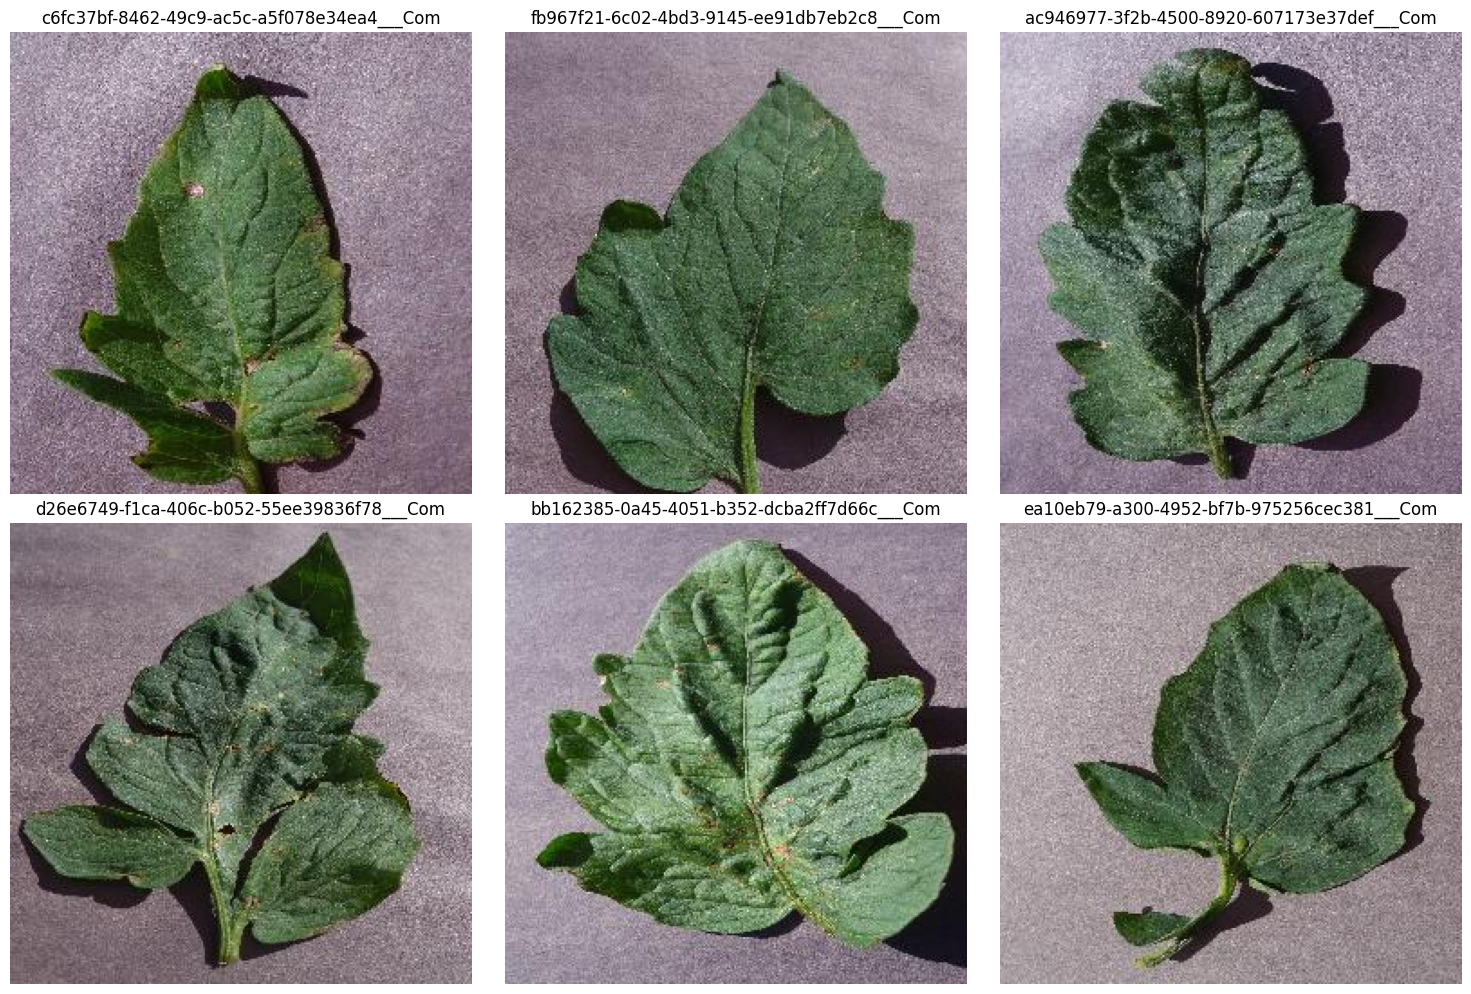

In [36]:
# 탐색적 데이터 분석 EDA 과정

# 이미지가 저장된 디렉토리 경로
path = "/Users/umjirana/tomatoleaf/tomato/train/Tomato___Target_Spot"

# 디렉토리 내 모든 이미지 파일 이름을 리스트로 가져오기
image_files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

# 처음 6장의 이미지를 라벨과 함께 출력하기
fig, axs = plt.subplots(2, 3, figsize=(15, 10))  # 2행 3열의 서브플롯 생성

for i in range(6):
    # 이미지 파일 이름과 해당 라벨 가져오기
    image_file = image_files[i]
    label = image_file.split('.')[0]  # 파일명에서 라벨 추출

    # 이미지 불러오고 화면에 출력하기
    img_path = os.path.join(path, image_file)
    img = mpimg.imread(img_path)
    ax = axs[i // 3, i % 3]  # 2행 3열 형태로 배치
    ax.imshow(img)
    ax.axis('off')  # 축 눈금 숨기기
    ax.set_title(label)  # 이미지 제목(라벨) 설정

plt.tight_layout()  # 서브플롯 간 여백 자동 조정
plt.show()  # 이미지 전체 출력

In [37]:
# 사전 학습된 DenseNet121 모델을 불러와 특징 추출기로 사용
conv_base = DenseNet121(
    weights='imagenet',          # ImageNet 데이터셋으로 사전 학습된 가중치 사용
    include_top=False,           # 최상단 분류기 층은 제외 (사용자 정의 출력층을 추가할 예정)
    input_shape=(256, 256, 3),   # 입력 이미지 크기 (256x256 RGB 이미지)
    pooling='avg'                # GlobalAveragePooling2D 적용하여 출력 벡터로 변환
)

In [38]:
conv_base.trainable = False  # conv_base의 가중치를 학습하지 않도록 고정

In [39]:
model = Sequential()  # 순차적으로 레이어를 쌓는 Sequential 모델 생성
model.add(conv_base)  # 사전 학습된 DenseNet121 모델 추가 (이미지 특징 추출기 역할)
model.add(BatchNormalization())  # 배치 정규화: 학습 안정성 및 속도 향상
model.add(Dense(256, activation='relu'))  # 은닉층 (노드 256개, ReLU 활성화 함수)
model.add(Dropout(0.35))  # 과적합 방지를 위한 드롭아웃 (35% 확률로 뉴런 비활성화)
model.add(BatchNormalization())  # 다시 배치 정규화
model.add(Dense(120, activation='relu'))  # 두 번째 은닉층 (노드 120개, ReLU 함수 사용)
model.add(Dense(10, activation='softmax'))  # 출력층 (클래스 10개 분류, 소프트맥스로 확률 출력)

In [40]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),             # Adam 최적화 알고리즘 사용 (학습률 0.0001로 설정)
    loss='categorical_crossentropy',       # 다중 클래스 분류를 위한 손실 함수 (라벨이 one-hot 인코딩일 때 사용)
    metrics=['accuracy']                   # 모델 평가 지표로 정확도(accuracy) 사용
)

In [41]:
# 모델 학습
history = model.fit(
    train_data,                          # 학습에 사용할 데이터셋 (train_data)
    epochs=5,                          # 최대 100 에폭(epoch) 동안 학습
    validation_data=val_data,           # 학습 중 성능 평가를 위한 검증 데이터셋
    callbacks=[EarlyStopping(patience=0)]  # 조기 종료 설정: 성능이 더 이상 개선되지 않으면 바로 학습 중단
)

Epoch 1/5


313/313 ━━━━━━━━━━━━━━━━━━━━ 623s 2s/step - accuracy: 0.3459 - loss: 1.9401 - val_accuracy: 0.7480 - val_loss: 0.9288
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 740s 2s/step - accuracy: 0.7536 - loss: 0.7817 - val_accuracy: 0.8330 - val_loss: 0.5374
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 826s 3s/step - accuracy: 0.8324 - loss: 0.5358 - val_accuracy: 0.8660 - val_loss: 0.4062
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1231s 4s/step - accuracy: 0.8679 - loss: 0.4123 - val_accuracy: 0.8920 - val_loss: 0.3345
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1713s 5s/step - accuracy: 0.8912 - loss: 0.3417 - val_accuracy: 0.8950 - val_loss: 0.2974


In [42]:
# 검증 데이터로 모델 평가
evaluation = model.evaluate(val_data)

# 평가 지표 출력
print("검증 손실(Validation Loss):", evaluation[0])
print("검증 정확도(Validation Accuracy):", evaluation[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step - accuracy: 0.8840 - loss: 0.3135
검증 손실(Validation Loss): 0.2974221706390381
검증 정확도(Validation Accuracy): 0.8949999809265137


In [43]:
# 추가 학습 (6~10번째 에폭 수행)
history_additional = model.fit(
    train_data,
    epochs=10,                # 총 에폭 목표: 10
    initial_epoch=5,          # 이전 학습이 0~4였으므로 5부터 시작
    validation_data=val_data,
    callbacks=[EarlyStopping(patience=0)]
)

# 추가 학습 후 다시 평가
evaluation = model.evaluate(val_data)

# 평가 지표 출력
print("검증 손실(Validation Loss):", evaluation[0])
print("검증 정확도(Validation Accuracy):", evaluation[1])

Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 546s 2s/step - accuracy: 0.9065 - loss: 0.2881 - val_accuracy: 0.9070 - val_loss: 0.2644
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2396s 8s/step - accuracy: 0.9224 - loss: 0.2457 - val_accuracy: 0.9160 - val_loss: 0.2438
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2516s 8s/step - accuracy: 0.9331 - loss: 0.2181 - val_accuracy: 0.9260 - val_loss: 0.2243
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 691s 2s/step - accuracy: 0.9356 - loss: 0.1944 - val_accuracy: 0.9280 - val_loss: 0.2130
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.9501 - loss: 0.1657 - val_accuracy: 0.9290 - val_loss: 0.2036
32/32 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9285 - loss: 0.2114
검증 손실(Validation Loss): 0.20355375111103058
검증 정확도(Validation Accuracy): 0.9290000200271606


In [44]:
class_names = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


/opt/homebrew/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


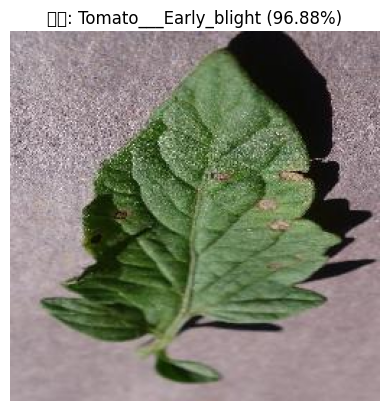

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

# 예측할 이미지 경로
img_path = '/Users/umjirana/Desktop/python/tomato23.jpg'  # 예시

# 이미지 로드 및 전처리
img = image.load_img(img_path, target_size=(256, 256))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # 정규화
img_array = np.expand_dims(img_array, axis=0)  # 배치 차원 추가

# 예측 수행
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

plt.imshow(img)
plt.axis('off')
plt.title(f"예측: {class_names[predicted_class]} ({confidence * 100:.2f}%)")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


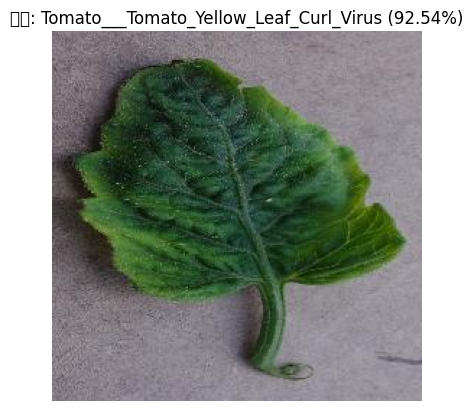

In [46]:
# 예측할 이미지 경로
img_path = '/Users/umjirana/Desktop/python/Tomato_Yellow.jpg'  # 예시

# 이미지 로드 및 전처리
img = image.load_img(img_path, target_size=(256, 256))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # 정규화
img_array = np.expand_dims(img_array, axis=0)  # 배치 차원 추가

# 예측 수행
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

plt.imshow(img)
plt.axis('off')
plt.title(f"예측: {class_names[predicted_class]} ({confidence * 100:.2f}%)")
plt.show()